# Order Delivery Time Prediction

## Objectives
The objective of this assignment is to build a regression model that predicts the delivery time for orders placed through Porter. The model will use various features such as the items ordered, the restaurant location, the order protocol, and the availability of delivery partners.

The key goals are:
- Predict the delivery time for an order based on multiple input features
- Improve delivery time predictions to optimiae operational efficiency
- Understand the key factors influencing delivery time to enhance the model's accuracy

## Data Pipeline
The data pipeline for this assignment will involve the following steps:
1. **Data Loading**
2. **Data Preprocessing and Feature Engineering**
3. **Exploratory Data Analysis**
4. **Model Building**
5. **Model Inference**

## Data Understanding
The dataset contains information on orders placed through Porter, with the following columns:

| Field                     | Description                                                                                 |
|---------------------------|---------------------------------------------------------------------------------------------|
| market_id                 | Integer ID representing the market where the restaurant is located.                         |
| created_at                | Timestamp when the order was placed.                                                        |
| actual_delivery_time      | Timestamp when the order was delivered.                                                     |
| store_primary_category    | Category of the restaurant (e.g., fast food, dine-in).                                      |
| order_protocol            | Integer representing how the order was placed (e.g., via Porter, call to restaurant, etc.). |
| total_items               | Total number of items in the order.                                                         |
| subtotal                  | Final price of the order.                                                                   |
| num_distinct_items        | Number of distinct items in the order.                                                      |
| min_item_price            | Price of the cheapest item in the order.                                                    |
| max_item_price            | Price of the most expensive item in the order.                                              |
| total_onshift_dashers     | Number of delivery partners on duty when the order was placed.                              |
| total_busy_dashers        | Number of delivery partners already occupied with other orders.                             |
| total_outstanding_orders  | Number of orders pending fulfillment at the time of the order.                              |
| distance                  | Total distance from the restaurant to the customer.                                         |


## **Importing Necessary Libraries**

In [1]:
# Import essential libraries for data manipulation and analysis

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
!pip install openpyxl


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## **1. Loading the data**
Load 'porter_data_1.csv' as a DataFrame

In [2]:

df=pd.read_csv("porter_data_1.csv")

## **2. Data Preprocessing and Feature Engineering** <font color = red>[15 marks]</font> <br>

#### **2.1 Fixing the Datatypes**  <font color = red>[5 marks]</font> <br>
The current timestamps are in object format and need conversion to datetime format for easier handling and intended functionality

##### **2.1.1** <font color = red>[2 marks]</font> <br>
Convert date and time fields to appropriate data type

In [3]:
# Convert 'created_at' and 'actual_delivery_time' columns to datetime format

df["created_at"] = pd.to_datetime(
    df["created_at"], format="%Y-%m-%d %H:%M:%S", errors="coerce"
)
df["actual_delivery_time"] = pd.to_datetime(
    df["actual_delivery_time"], format="%Y-%m-%d %H:%M:%S", errors="coerce"
)
print(df.dtypes)
print(df.head())


market_id                          float64
created_at                  datetime64[us]
actual_delivery_time        datetime64[us]
store_primary_category               int64
order_protocol                     float64
total_items                          int64
subtotal                             int64
num_distinct_items                   int64
min_item_price                       int64
max_item_price                       int64
total_onshift_dashers              float64
total_busy_dashers                 float64
total_outstanding_orders           float64
distance                           float64
dtype: object
   market_id          created_at actual_delivery_time  store_primary_category  \
0        1.0 2015-02-06 22:24:17  2015-02-06 23:11:17                       4   
1        2.0 2015-02-10 21:49:25  2015-02-10 22:33:25                      46   
2        2.0 2015-02-16 00:11:35  2015-02-16 01:06:35                      36   
3        1.0 2015-02-12 03:36:46  2015-02-12 04:35:46       

##### **2.1.2**  <font color = red>[3 marks]</font> <br>
Convert categorical fields to appropriate data type

In [4]:
# Convert categorical features to category type
cat_cols = ["store_primary_category","order_protocol"]
df[cat_cols] = df[cat_cols].astype("category")
print (df.dtypes)
print (df.head())


market_id                          float64
created_at                  datetime64[us]
actual_delivery_time        datetime64[us]
store_primary_category            category
order_protocol                    category
total_items                          int64
subtotal                             int64
num_distinct_items                   int64
min_item_price                       int64
max_item_price                       int64
total_onshift_dashers              float64
total_busy_dashers                 float64
total_outstanding_orders           float64
distance                           float64
dtype: object
   market_id          created_at actual_delivery_time store_primary_category  \
0        1.0 2015-02-06 22:24:17  2015-02-06 23:11:17                      4   
1        2.0 2015-02-10 21:49:25  2015-02-10 22:33:25                     46   
2        2.0 2015-02-16 00:11:35  2015-02-16 01:06:35                     36   
3        1.0 2015-02-12 03:36:46  2015-02-12 04:35:46           

#### **2.2 Feature Engineering** <font color = red>[5 marks]</font> <br>
Calculate the time taken to execute the delivery as well as extract the hour and day at which the order was placed

##### **2.2.1** <font color = red>[2 marks]</font> <br>
Calculate the time taken using the features `actual_delivery_time` and `created_at`

In [5]:
# Calculate time taken in minutes
df['time_taken'] = df['actual_delivery_time'] - df['created_at']
df['time_taken_hours'] = df['time_taken'].dt.total_seconds() / 3600
print(df[['created_at', 'actual_delivery_time', 'time_taken', 'time_taken_hours',]].head())


           created_at actual_delivery_time      time_taken  time_taken_hours
0 2015-02-06 22:24:17  2015-02-06 23:11:17 0 days 00:47:00          0.783333
1 2015-02-10 21:49:25  2015-02-10 22:33:25 0 days 00:44:00          0.733333
2 2015-02-16 00:11:35  2015-02-16 01:06:35 0 days 00:55:00          0.916667
3 2015-02-12 03:36:46  2015-02-12 04:35:46 0 days 00:59:00          0.983333
4 2015-01-27 02:12:36  2015-01-27 02:58:36 0 days 00:46:00          0.766667


##### **2.2.2** <font color = red>[3 marks]</font> <br>
Extract the hour at which the order was placed and which day of the week it was. Drop the unnecessary columns.

In [6]:
# Extract the hour and day of week from the 'created_at' timestamp

df['created_at'] = pd.to_datetime(df['created_at'])

df['order_hour'] = df['created_at'].dt.hour
df['order_day'] = df['created_at'].dt.day_name()
# Create a categorical feature 'isWeekend'

df['isWeekend'] = df['order_day'].isin(['Saturday' , 'Sunday'])
df = df.drop(columns=['distance', 'subtotal'], errors='ignore')

print(df[['created_at', 'order_hour', 'order_day', 'isWeekend']].head())

           created_at  order_hour order_day  isWeekend
0 2015-02-06 22:24:17          22    Friday      False
1 2015-02-10 21:49:25          21   Tuesday      False
2 2015-02-16 00:11:35           0    Monday      False
3 2015-02-12 03:36:46           3  Thursday      False
4 2015-01-27 02:12:36           2   Tuesday      False


In [7]:
# Drop unnecessary columns


#### **2.3 Creating training and validation sets** <font color = red>[5 marks]</font> <br>

##### **2.3.1** <font color = red>[2 marks]</font> <br>
 Define target and input features

In [8]:
# Define target variable (y) and features (X)

target = 'time_taken_hours'

input_features = [
    'order_hour',
    'order_day',
    'isWeekend',
    'store_primary_category',
    'order_protocol',
    'total_items',
    'num_distinct_items',
    'min_item_price',
    'max_item_price',
    'total_onshift_dashers',
    'total_busy_dashers',
    'total_outstanding_orders'
]
    

##### **2.3.2** <font color = red>[3 marks]</font> <br>
 Split the data into training and test sets

In [9]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split

# 1. Define X (input feature) and y (target)
X = df[input_features] 
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



## **3. Exploratory Data Analysis on Training Data** <font color = red>[20 marks]</font> <br>
1. Analyzing the correlation between variables to identify patterns and relationships
2. Identifying and addressing outliers to ensure the integrity of the analysis
3. Exploring the relationships between variables and examining the distribution of the data for better insights

#### **3.1 Feature Distributions** <font color = red> [7 marks]</font> <br>


In [10]:
# Define numerical and categorical columns for easy EDA and data manipulation
import numpy as np
cat_cols = df.select_dtypes(include=['category', 'object']).columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)


Categorical columns: ['store_primary_category', 'order_protocol', 'order_day']
Numerical columns: ['market_id', 'total_items', 'num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders', 'time_taken', 'time_taken_hours', 'order_hour']


/var/folders/kp/b1pbq_b14dz9nb_9gqv7k_3c0000gn/T/ipykernel_6694/379810208.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['category', 'object']).columns.tolist()


##### **3.1.1** <font color = red>[3 marks]</font> <br>
Plot distributions for numerical columns in the training set to understand their spread and any skewness

Numerical columns to plot: ['order_hour', 'total_items', 'num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders']


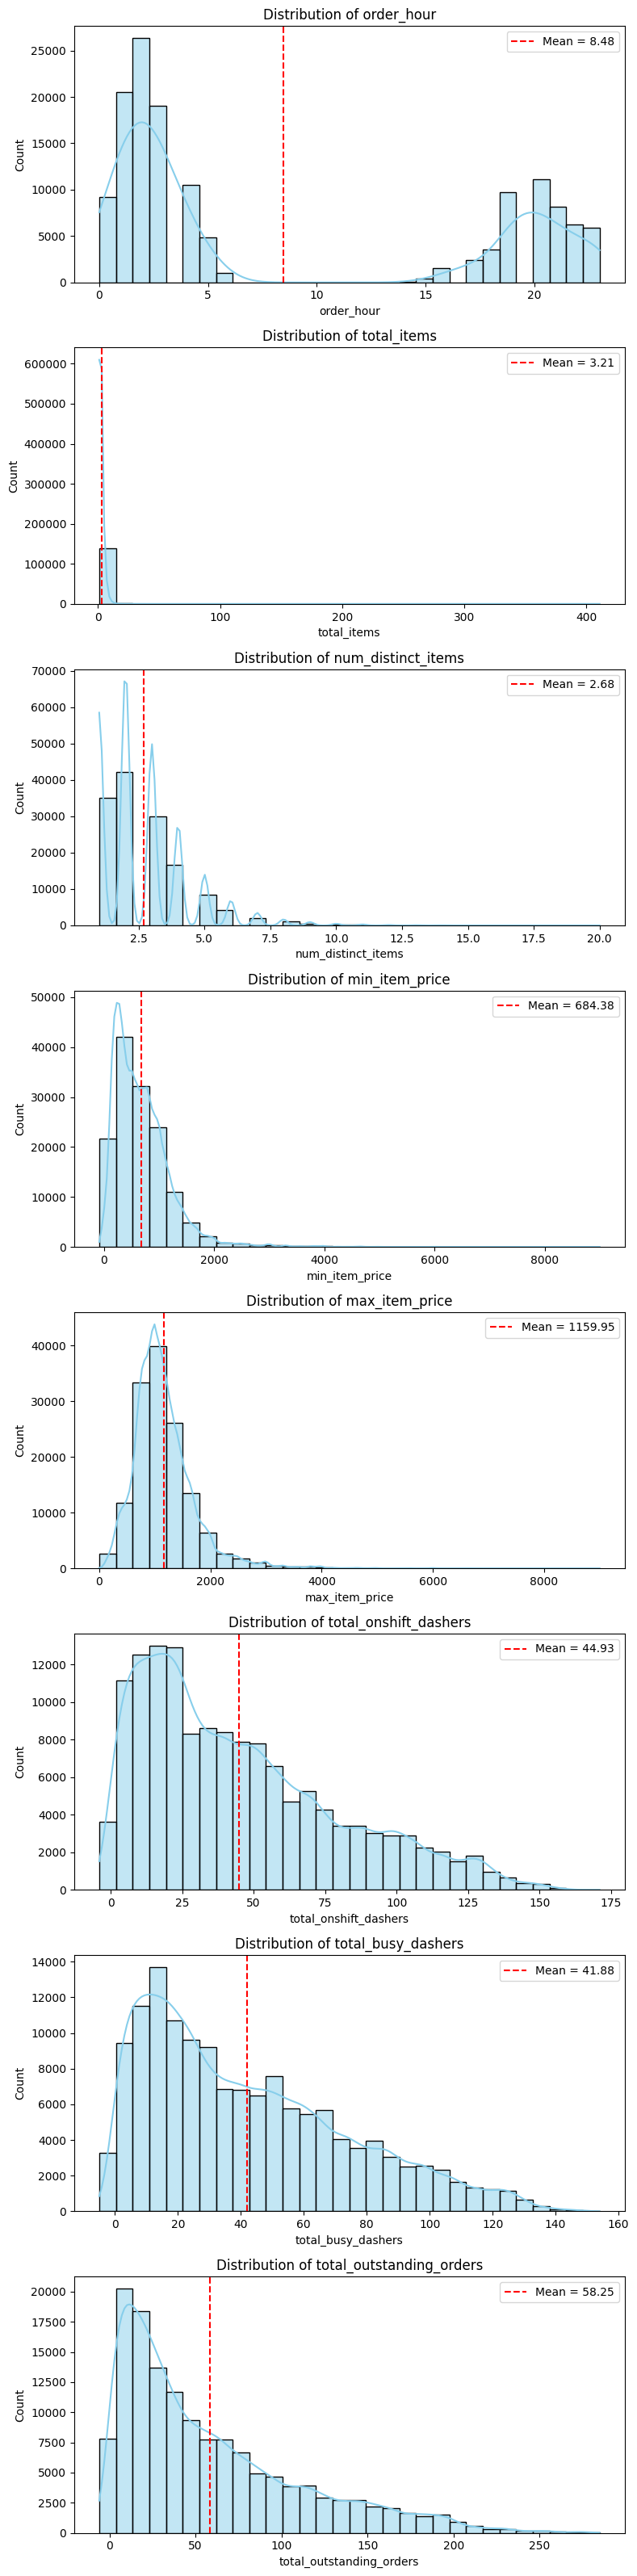

In [11]:
# Plot distributions for all numerical columns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbs

X_train = X_train.replace([np.inf, -np.inf], np.nan)

num_cols = X_train.select_dtypes(include=[float, int]).columns.tolist()
print("Numerical columns to plot:", num_cols)

plt.figure(figsize=(8, 4* len(num_cols)))
for i, col in enumerate(num_cols, start=1):
    ax = plt.subplot(len(num_cols), 1, i)
    sns.histplot(
        X_train[col].dropna(),
        kde=True,
        bins=30,
        color="skyblue",
        edgecolor="black"
    )
    ax.set_title(f'Distribution of {col}')
    mean_val = X_train[col].mean()
    ax.axvline(mean_val, color='red', linestyle='--', label=f'Mean = {mean_val:.2f}')
    ax.legend()
plt.tight_layout()
plt.show()

##### **3.1.2** <font color = red>[2 marks]</font> <br>
Check the distribution of categorical features


Value counts for 'store_primary_category':
store_primary_category
4     18183
55    15745
46    15586
13     9915
58     8995
      ...  
1        10
43        9
8         2
3         1
21        1
Name: count, Length: 73, dtype: int64
----------------------------------------

Value counts for 'order_protocol':
order_protocol
1.0    48404
3.0    47125
5.0    41415
2.0    20890
4.0    17246
6.0      678
7.0       19
Name: count, dtype: int64
----------------------------------------

Value counts for 'order_day':
order_day
Saturday     30858
Sunday       29893
Friday       25004
Monday       24202
Thursday     22584
Wednesday    21753
Tuesday      21483
Name: count, dtype: int64
----------------------------------------


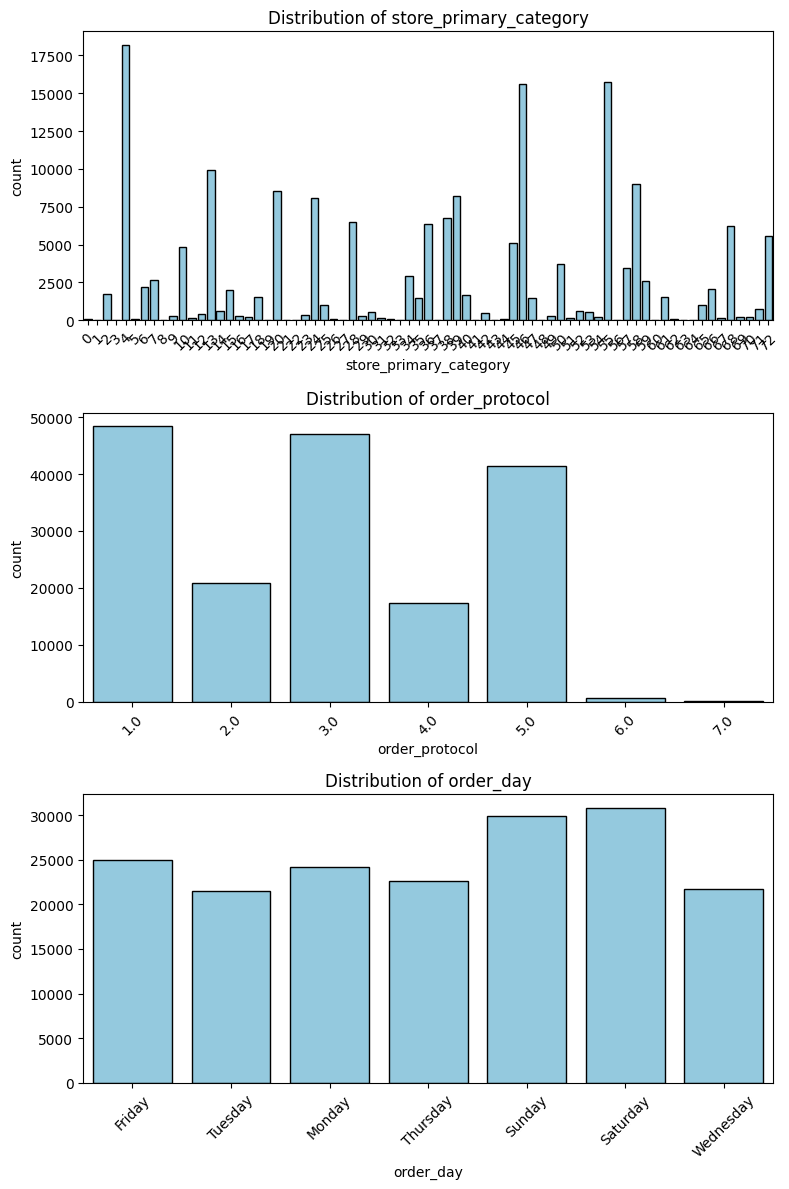

Rows and columns: (175777, 17)
Columns: ['market_id', 'created_at', 'actual_delivery_time', 'store_primary_category', 'order_protocol', 'total_items', 'num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders', 'time_taken', 'time_taken_hours', 'order_hour', 'order_day', 'isWeekend']


In [12]:
# Distribution of categorical columns

if 'order_day' not in df.columns:
    df['order_day'] = df ['created_at'].dt,day_name()
    print("Created 'order_day' column.")

cat_cols = ['store_primary_category', 'order_protocol', 'order_day']

for col in cat_cols:
    print(f"\nValue counts for '{col}':")
    print(df[col].value_counts())
    print("-" * 40)

plt.figure(figsize=(8, 4 * len(cat_cols)))
for i, col in enumerate(cat_cols, 1):
    ax = plt.subplot(len(cat_cols), 1, i)
    sns.countplot(data=df, x=col, color='skyblue', edgecolor='black')
    ax.set_title(f"Distribution of {col}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("Rows and columns:", df.shape)
print("Columns:", df.columns.tolist())

##### **3.1.3** <font color = red>[2 mark]</font> <br>
Visualise the distribution of the target variable to understand its spread and any skewness

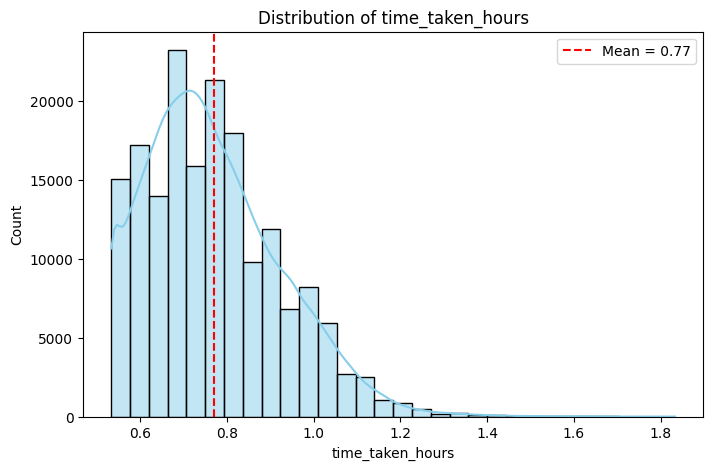

In [13]:
# Distribution of time_taken
df[target] = df[target].replace([np.inf, -np.inf], np.nan)

plt.figure(figsize=(8, 5))
sns.histplot(
    data=df, x=target, 
    bins=30,
    kde=True,
    color="skyblue",
    edgecolor="black"
)
plt.title(f'Distribution of {target}')
plt.xlabel(target)
plt.ylabel('Count')

mean_val = df[target].mean()
median_val = df[target].median()
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean = {mean_val:.2f}')
plt.legend()
plt.show()



#### **3.2 Relationships Between Features** <font color = red>[3 marks]</font> <br>

##### **3.2.1** <font color = red>[3 marks]</font> <br>
Scatter plots for important numerical and categorical features to observe how they relate to `time_taken`

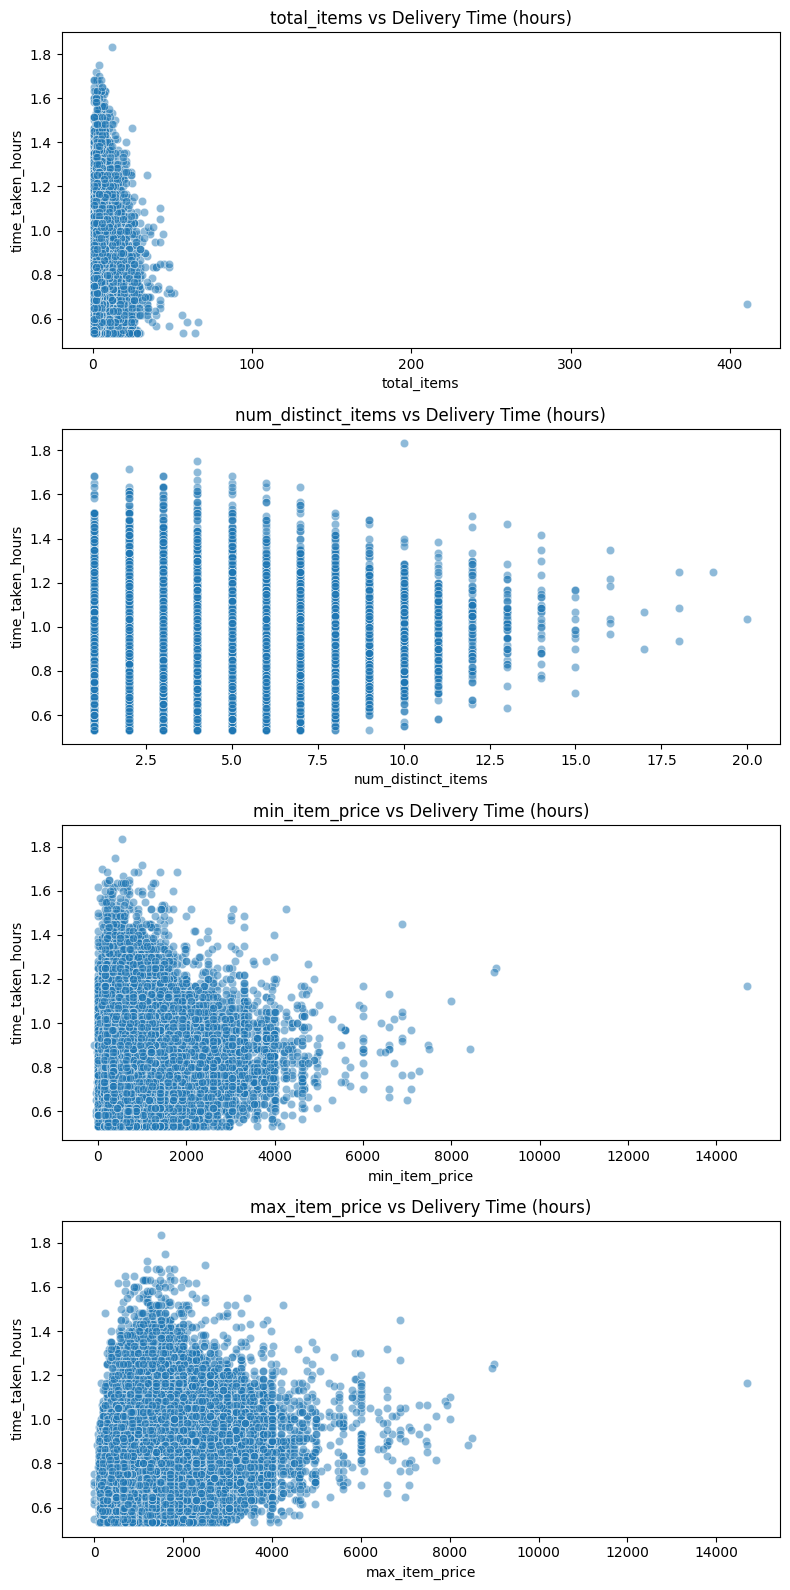

/var/folders/kp/b1pbq_b14dz9nb_9gqv7k_3c0000gn/T/ipykernel_6694/3329230336.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y ='time_taken_hours', showfliers=False, palette="pastel")
/var/folders/kp/b1pbq_b14dz9nb_9gqv7k_3c0000gn/T/ipykernel_6694/3329230336.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y ='time_taken_hours', showfliers=False, palette="pastel")
/var/folders/kp/b1pbq_b14dz9nb_9gqv7k_3c0000gn/T/ipykernel_6694/3329230336.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=co

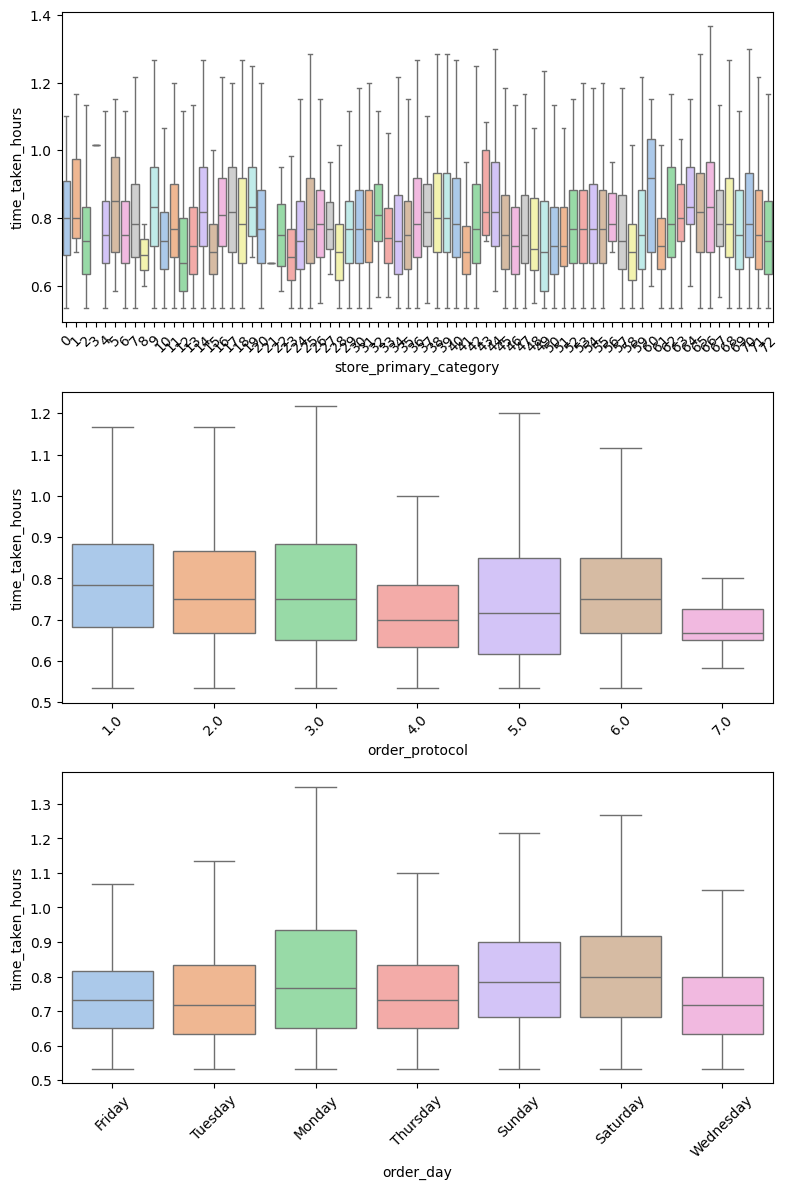

In [14]:
# Scatter plot to visualise the relationship between time_taken and other features

num_features = ['total_items', 'num_distinct_items', 'min_item_price', 'max_item_price']
cat_features = ['store_primary_category', 'order_protocol', 'order_day']

plt.figure(figsize=(8, 4 * len(num_features)))
for i, col in enumerate(num_features, 1):
    ax = plt.subplot(len(num_features), 1, i)
    sns.scatterplot(data=df, x=col, y='time_taken_hours', alpha=0.5)
    ax.set_title(f"{col} vs Delivery Time (hours)")
    ax.set_xlabel(col)
    ax.set_ylabel('time_taken_hours')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4 * len(cat_features)))
for i, col in enumerate(cat_features, 1):
    ax = plt.subplot(len(cat_features), 1, i)
    sns.boxplot(data=df, x=col, y ='time_taken_hours', showfliers=False, palette="pastel")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [15]:
# Show the distribution of time_taken for different hours



#### **3.3 Correlation Analysis** <font color = red>[5 marks]</font> <br>
Check correlations between numerical features to identify which variables are strongly related to `time_taken`

##### **3.3.1** <font color = red>[3 marks]</font> <br>
Plot a heatmap to display correlations

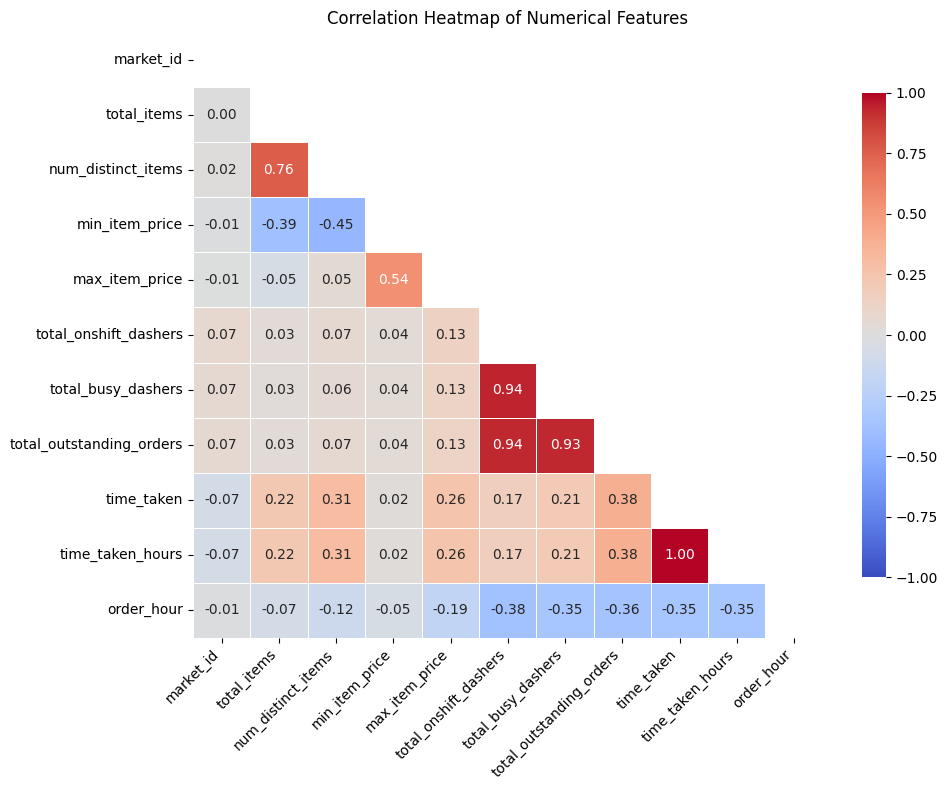

In [16]:
# Plot the heatmap of the correlation matrix

num_df = df.select_dtypes(include=[np.number])

corr_matrix = num_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f", 
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap of Numerical Features")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

##### **3.3.2** <font color = red>[2 marks]</font> <br>
Drop the columns with weak correlations with the target variable

In [17]:
# Drop 3-5 weakly correlated columns from training dataset
import numpy as np

num_df = df.select_dtypes(include=[np.number])
corr_with_target = num_df.corr()[target].drop(target)
print("Correlation with target:\n", corr_with_target)

weak_features = corr_with_target [corr_with_target.abs() < 0.2 ].index.tolist()
print("\nDropping(|corr|<0.2):", weak_features)

upper = num_df.corr().abs().where(np.triu(np.ones_like(num_df.corr().abs()), k=1).astype(bool))
high_corr = [col for col in upper.columns if any(upper[col] > 0.95)]
print("also dropping redundant features:", high_corr)

df_reduced = df.drop(columns=weak_features + high_corr)
print("\nColumns left:", df_reduced.columns.tolist())


Correlation with target:
 market_id                  -0.073016
total_items                 0.224856
num_distinct_items          0.312055
min_item_price              0.022753
max_item_price              0.255167
total_onshift_dashers       0.171015
total_busy_dashers          0.206045
total_outstanding_orders    0.384999
time_taken                  1.000000
order_hour                 -0.346366
Name: time_taken_hours, dtype: float64

Dropping(|corr|<0.2): ['market_id', 'min_item_price', 'total_onshift_dashers']
also dropping redundant features: ['time_taken_hours']

Columns left: ['created_at', 'actual_delivery_time', 'store_primary_category', 'order_protocol', 'total_items', 'num_distinct_items', 'max_item_price', 'total_busy_dashers', 'total_outstanding_orders', 'time_taken', 'order_hour', 'order_day', 'isWeekend']


#### **3.4 Handling the Outliers** <font color = red>[5 marks]</font> <br>



##### **3.4.1** <font color = red>[2 marks]</font> <br>
Visualise potential outliers for the target variable and other numerical features using boxplots

Columns in DataFrame:
 ['market_id', 'created_at', 'actual_delivery_time', 'store_primary_category', 'order_protocol', 'total_items', 'num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders', 'time_taken', 'time_taken_hours', 'order_hour', 'order_day', 'isWeekend']
Numeric columns detected: ['market_id', 'total_items', 'num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders', 'time_taken', 'time_taken_hours', 'order_hour']
Plotting boxplots for: ['time_taken_hours', 'total_items', 'min_item_price', 'max_item_price']


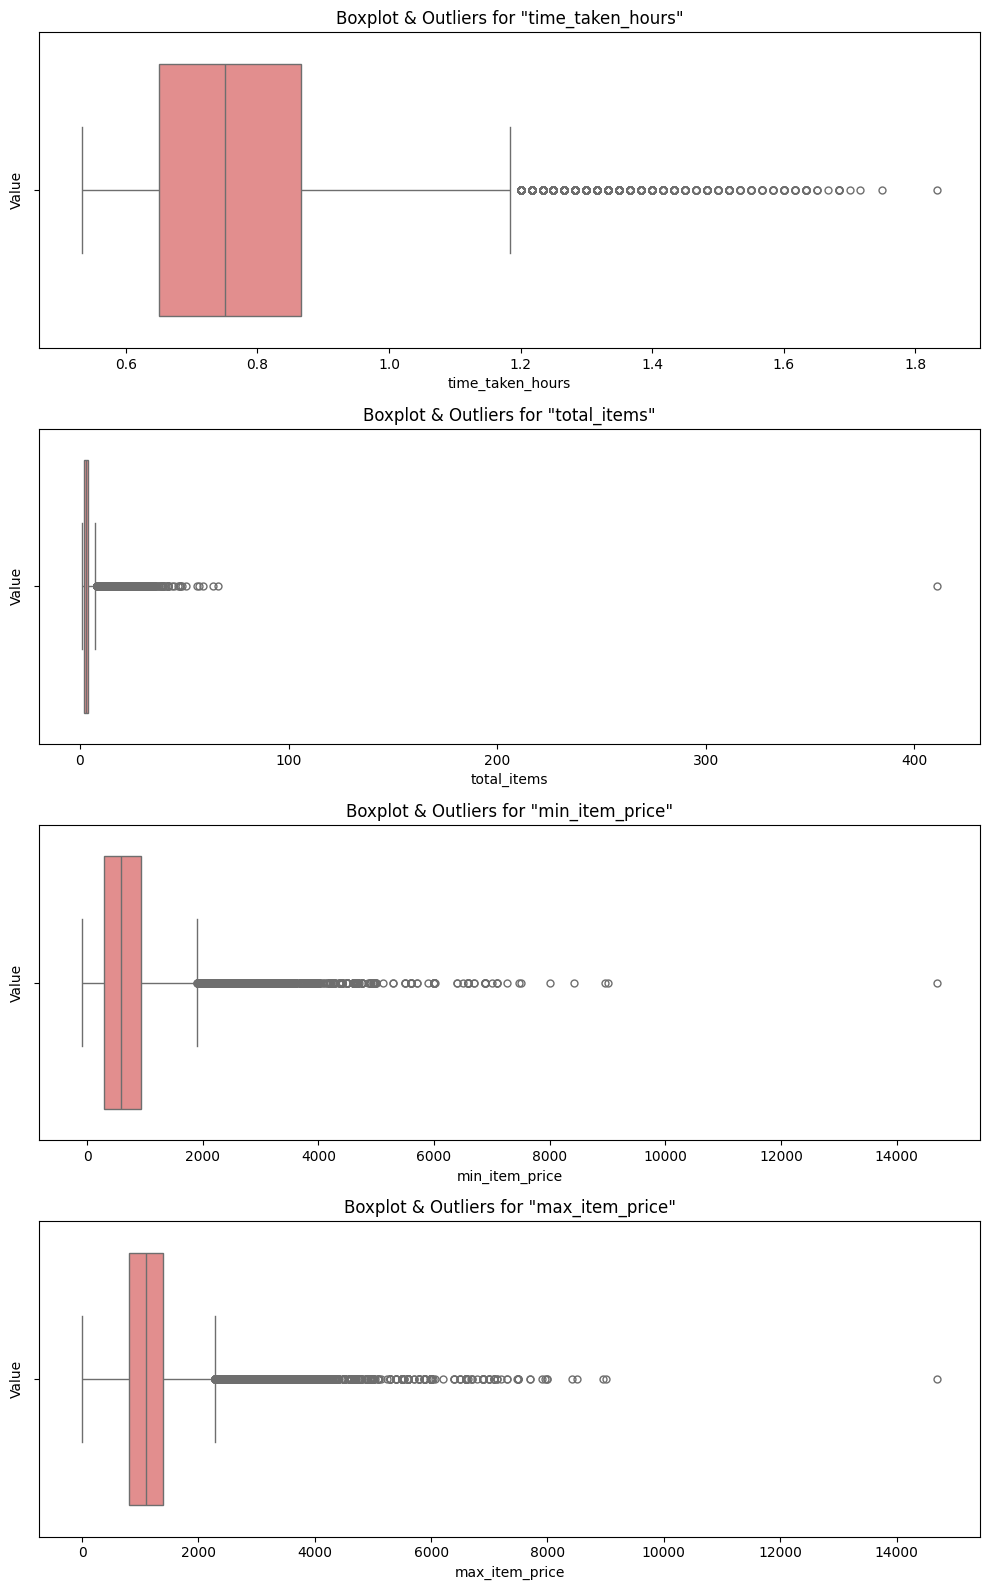

In [18]:
# Boxplot for time_taken

print("Columns in DataFrame:\n", df.columns.tolist())
num_cols_current = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns detected:", num_cols_current)

wanted = ['time_taken_hours', 'total_items', 'min_item_price', 'max_item_price']
outlier_cols = [col for col in wanted if col in num_cols_current]
print("Plotting boxplots for:", outlier_cols)

# Plot boxplots
plt.figure(figsize=(10, 4 * len(outlier_cols)))
for i, col in enumerate(outlier_cols, 1):
    ax = plt.subplot(len(outlier_cols), 1, i)
    sns.boxplot(x=df[col], color='lightcoral', showfliers=True, fliersize=5)
    ax.set_title(f'Boxplot & Outliers for "{col}"')
    ax.set_xlabel(col)
    ax.set_ylabel('Value')
plt.tight_layout()
plt.show()



##### **3.4.2** <font color = red>[3 marks]</font> <br>
Handle outliers present in all columns

In [19]:
# Handle outliers

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in num_cols:
    # Calculate quartiles and IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    n_outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"{col}: {n_outliers} outliers detected")
    
   
    df = df[(df[col] >= lower) & (df[col] <= upper)]
    # 🎯 or Option B: Cap them (uncomment below instead of the drop above)
    # df[col] = np.clip(df[col], lower, upper)


print("\nShape after handling outliers:", df.shape)

market_id: 0 outliers detected
total_items: 8486 outliers detected
num_distinct_items: 1043 outliers detected
min_item_price: 3977 outliers detected
max_item_price: 4238 outliers detected
total_onshift_dashers: 1302 outliers detected
total_busy_dashers: 414 outliers detected
total_outstanding_orders: 5083 outliers detected
time_taken: 2400 outliers detected
time_taken_hours: 0 outliers detected
order_hour: 0 outliers detected

Shape after handling outliers: (148834, 17)


## **4. Exploratory Data Analysis on Validation Data** <font color = red>[optional]</font> <br>
Optionally, perform EDA on test data to see if the distribution match with the training data

#### **4.1 Feature Distributions**


##### **4.1.1**
Plot distributions for numerical columns in the validation set to understand their spread and any skewness

##### **4.1.2**
Check the distribution of categorical features

##### **4.1.3**
Visualise the distribution of the target variable to understand its spread and any skewness

#### **4.2 Relationships Between Features**
Scatter plots for numerical features to observe how they relate to each other, especially to `time_taken`

#### **4.3** Drop the columns with weak correlations with the target variable

## **5. Model Building** <font color = red>[15 marks]</font> <br>

#### **Import Necessary Libraries**

In [20]:
# Import libraries

import numpy as np                  
import pandas as pd                

import matplotlib.pyplot as plt     
import seaborn as sns               

from sklearn.model_selection import train_test_split  
from sklearn.preprocessing import StandardScaler     
from sklearn.linear_model import LinearRegression    
from sklearn.metrics import mean_squared_error, r2_score  


#### **5.1 Feature Scaling** <font color = red>[3 marks]</font> <br>

In [21]:
# Apply scaling to the numerical columns

from sklearn.preprocessing import StandardScaler

numeric_feats = df.select_dtypes(include='number', exclude=['timedelta', 'timedelta64']).columns.tolist()

print("Numeric columns to be scaled:", numeric_feats)

scaler = StandardScaler()


df[numeric_feats] = scaler.fit_transform(df[numeric_feats])

print("Feature means (≈0):", df[numeric_feats].mean().round(2).tolist())
print("Feature stds  (≈1):", df[numeric_feats].std().round(2).tolist())

Numeric columns to be scaled: ['market_id', 'total_items', 'num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders', 'time_taken_hours', 'order_hour']
Feature means (≈0): [-0.0, -0.0, -0.0, 0.0, -0.0, 0.0, -0.0, 0.0, 0.0, 0.0]
Feature stds  (≈1): [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


Note that linear regression is agnostic to feature scaling. However, with feature scaling, we get the coefficients to be somewhat on the same scale so that it becomes easier to compare them.

#### **5.2 Build a linear regression model** <font color = red>[5 marks]</font> <br>

You can choose from the libraries *statsmodels* and *scikit-learn* to build the model.

In [22]:
# Create/Initialise the model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

if 'time_taken_hours' not in df.columns and 'actual_delivery_time' in df.columns:
    df['time_taken_hours'] = (
        pd.to_datetime(df['actual_delivery_time']) -
        pd.to_datetime(df['created_at'])
    ).dt.total_seconds() / 3600

# ✅ 2. Select only float & int features—exclude any timedeltas
feature_cols = df.select_dtypes(include='number', exclude=['timedelta', 'timedelta64']).columns.tolist()
feature_cols.remove('time_taken_hours')  # separate target
if 'time_taken' in feature_cols:
    feature_cols.remove('time_taken')  # drop leaked duplicate of target (minutes version)
print("Features used:", feature_cols)

X = df[feature_cols]
y = df['time_taken_hours']

# 🔄 3. Split into train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🧠 4. Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# 📈 5. Results
print("✅ Model trained successfully!")
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print("Train R²:", model.score(X_train, y_train))
print("Test R² :", model.score(X_test, y_test))

Features used: ['market_id', 'total_items', 'num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders', 'order_hour']
✅ Model trained successfully!
Coefficients: [-0.07231365  0.13797788  0.13578937  0.07372465  0.13030864 -1.38896978
 -0.46929285  1.88404851 -0.25525833]
Intercept: -0.0018123887808533204
Train R²: 0.5773178512210498
Test R² : 0.5808601944468824


In [23]:
# Train the model using the training data
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
if 'time_taken_hours' not in df.columns:
    df['time_taken_hours'] = (
        pd.to_datetime(df['actual_delivery_time']) -
        pd.to_datetime(df['created_at'])
    ).dt.total_seconds() / 3600

# 2️⃣ Select only true numeric features (exclude timedelta)
features = df.select_dtypes(
    include='number',
    exclude=['timedelta', 'timedelta64']
).columns.drop(['time_taken_hours', 'time_taken'], errors='ignore').tolist()
print("➡️ Features:", features)

X = df[features]
y = df['time_taken_hours']

# 3️⃣ Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4️⃣ Create and train the model
model = LinearRegression()  # Ordinary least squares regression :contentReference[oaicite:1]{index=1}
model.fit(X_train, y_train)

# 5️⃣ Evaluate the model
print("✅ Model trained!")
print("R² on training set:", model.score(X_train, y_train))
print("R² on test set    :", model.score(X_test, y_test))

➡️ Features: ['market_id', 'total_items', 'num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders', 'order_hour']
✅ Model trained!
R² on training set: 0.5773178512210498
R² on test set    : 0.5808601944468824


In [24]:
# Make predictions
from sklearn.metrics import mean_squared_error
import numpy as np

# 1️⃣ Rebuild the proper numeric_features list — exclude any timedelta columns
numeric_features = X_test.select_dtypes(
    include='number',
    exclude=['timedelta', 'timedelta64']
).columns.tolist()
print("✔️ Using features:", numeric_features)

# 2️⃣ Make predictions using only valid numeric features
y_pred = model.predict(X_test[numeric_features])

# 3️⃣ View some predictions vs actuals
print("\nSample Predictions:")
for pred, actual in zip(y_pred[:10], y_test.iloc[:10]):
    print(f"Predicted: {pred:.2f} hrs, Actual: {actual:.2f} hrs")

# 4️⃣ Calculate and display RMSE
rmse = mean_squared_error(y_test, y_pred) ** 0.5
print(f"\n✅ Test RMSE: {rmse:.2f} hours")

✔️ Using features: ['market_id', 'total_items', 'num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders', 'order_hour']

Sample Predictions:
Predicted: -1.43 hrs, Actual: -1.58 hrs
Predicted: -0.54 hrs, Actual: -0.58 hrs
Predicted: -0.02 hrs, Actual: -0.95 hrs
Predicted: 0.26 hrs, Actual: 0.55 hrs
Predicted: -0.51 hrs, Actual: 0.68 hrs
Predicted: 0.12 hrs, Actual: 0.43 hrs
Predicted: -0.85 hrs, Actual: -1.08 hrs
Predicted: 0.31 hrs, Actual: -0.45 hrs
Predicted: 0.34 hrs, Actual: -0.20 hrs
Predicted: 0.40 hrs, Actual: 1.05 hrs

✅ Test RMSE: 0.65 hours


In [25]:
# Find results for evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1️⃣ Generate predictions
y_pred = model.predict(X_test[numeric_features])

# 2️⃣ Compute evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

# 3️⃣ Display results
print(f"✅ Model Evaluation on Test Set:")
print(f"MAE  (mean absolute error)   : {mae:.2f} hours")
print(f"MSE  (mean squared error)    : {mse:.2f}")
print(f"RMSE (root mean squared error): {rmse:.2f} hours")
print(f"R²   (coefficient of determination): {r2:.2f}")


✅ Model Evaluation on Test Set:
MAE  (mean absolute error)   : 0.52 hours
MSE  (mean squared error)    : 0.42
RMSE (root mean squared error): 0.65 hours
R²   (coefficient of determination): 0.58


Note that we have 12 (depending on how you select features) training features. However, not all of them would be useful. Let's say we want to take the most relevant 8 features.

We will use Recursive Feature Elimination (RFE) here.

For this, you can look at the coefficients / p-values of features from the model summary and perform feature elimination, or you can use the RFE module provided with *scikit-learn*.

#### **5.3 Build the model and fit RFE to select the most important features** <font color = red>[7 marks]</font> <br>

For RFE, we will start with all features and use
the RFE method to recursively reduce the number of features one-by-one.

After analysing the results of these iterations, we select the one that has a good balance between performance and number of features.

In [26]:
# Loop through the number of features and test the model
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# 1. Prepare features and target
X = df[feature_cols]  # numeric feature list you built earlier
y = df['time_taken_hours']  # target column

# 2. Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Perform RFE loop
results = {}
for n in range(len(feature_cols), 0, -1):
    rfe = RFE(estimator=LinearRegression(), n_features_to_select=n, step=1)
    rfe.fit(X_train, y_train)

    sel = [feat for feat, keep in zip(feature_cols, rfe.support_) if keep]
    model = LinearRegression()
    model.fit(X_train[sel], y_train)

    r2 = r2_score(y_test, model.predict(X_test[sel]))
    results[n] = (r2, sel)
    print(f"{n:2d} features → R² = {r2:.3f}")

# 4. Choose best model by balancing R² and feature count
best_n, (best_r2, best_feats) = max(
    results.items(),
    key=lambda x: x[1][0] - 0.001 * x[0]
)
print(f"\n➡️ Best: {best_n} features with R² = {best_r2:.3f}")
print("Selected features:", best_feats)


 9 features → R² = 0.581
 8 features → R² = 0.575
 7 features → R² = 0.572
 6 features → R² = 0.570
 5 features → R² = 0.541
 4 features → R² = 0.496
 3 features → R² = 0.409
 2 features → R² = 0.383
 1 features → R² = 0.076

➡️ Best: 9 features with R² = 0.581
Selected features: ['market_id', 'total_items', 'num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders', 'order_hour']


In [27]:
# Build the final model with selected number of features
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# 1️⃣ Prepare data
X = df[feature_cols]  # your cleaned numeric feature list
y = df['time_taken_hours']

# 2️⃣ Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3️⃣ Initialize RFECV with LinearRegression
rfecv = RFECV(
    estimator=LinearRegression(),
    step=1,
    cv=5,
    scoring='r2'
)
rfecv.fit(X_train, y_train)

# 4️⃣ Retrieve selected features
selected = X_train.columns[rfecv.support_].tolist()
print(f"✅ Optimal number of features: {rfecv.n_features_}")
print("🎯 Selected features:", selected)

# 5️⃣ Train final model on selected features
final_model = LinearRegression()
final_model.fit(X_train[selected], y_train)

# 6️⃣ Evaluate performance
y_pred = final_model.predict(X_test[selected])
print("R² on test set:", round(r2_score(y_test, y_pred), 3))


✅ Optimal number of features: 9
🎯 Selected features: ['market_id', 'total_items', 'num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders', 'order_hour']
R² on test set: 0.581


## **6. Results and Inference** <font color = red>[5 marks]</font> <br>

#### **6.1 Perform Residual Analysis** <font color = red>[3 marks]</font> <br>

✅ RFE selected: ['total_outstanding_orders']


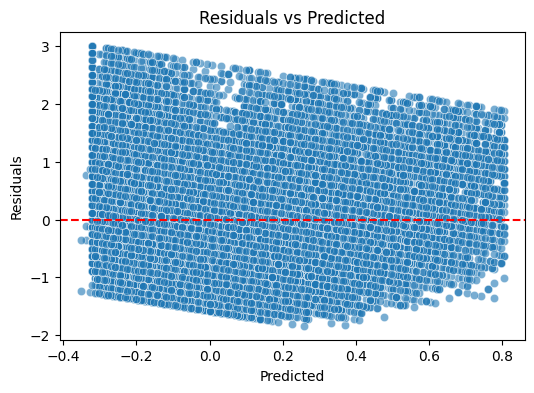

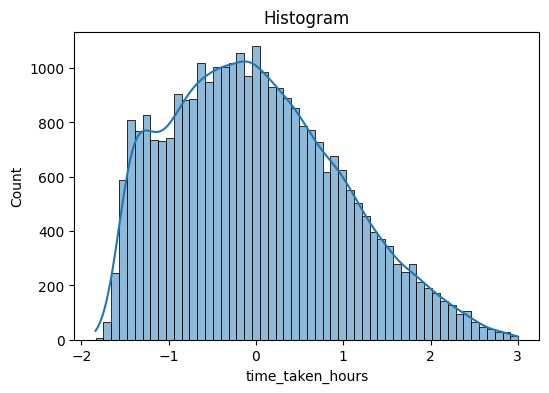

<Figure size 600x400 with 0 Axes>

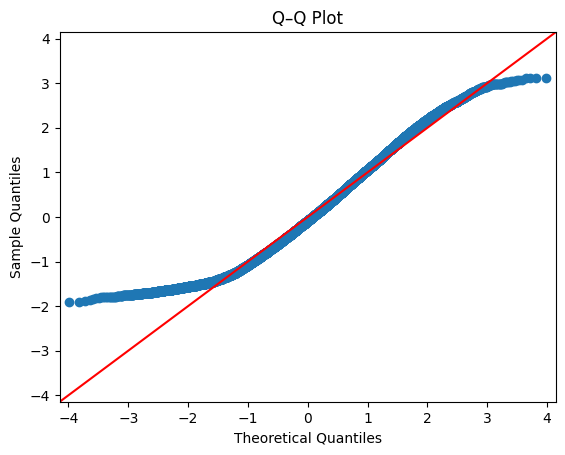

✅ Test RMSE: 0.97 hours


In [28]:
# Perform residual analysis using plots like residuals vs predicted values, Q-Q plot and residual histogram

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
selected_features = [
    feat for feat, keep in zip(feature_cols, rfe.support_)
    if keep
]
print("✅ RFE selected:", selected_features)

# A. Predictions using selected features
y_pred = model.predict(X_test[selected_features])
residuals = y_test - y_pred

# B. Residuals vs Predicted
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

# C. Histogram
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Histogram")
plt.show()

# D. Q-Q Plot
plt.figure(figsize=(6,4))
sm.qqplot(residuals, line='45', fit=True)
plt.title("Q–Q Plot")
plt.show()

# E. Final RMSE
rmse = mean_squared_error(y_test, y_pred) ** 0.5
print("✅ Test RMSE:", round(rmse, 2), "hours")

[Your inferences here:]



#### **6.2 Perform Coefficient Analysis** <font color = red>[2 marks]</font> <br>

Perform coefficient analysis to find how changes in features affect the target.
Also, the features were scaled, so interpret the scaled and unscaled coefficients to understand the impact of feature changes on delivery time.


In [29]:
# Compare the scaled vs unscaled features used in the final model

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Without scaling
model_raw = LinearRegression().fit(X_train, y_train)
y_pred_raw = model_raw.predict(X_test)
rmse_raw = mean_squared_error(y_test, y_pred_raw) ** 0.5

# With scaling
pipeline = make_pipeline(StandardScaler(), LinearRegression())
model_scaled = pipeline.fit(X_train, y_train)
y_pred_scaled = model_scaled.predict(X_test)
rmse_scaled = mean_squared_error(y_test, y_pred_scaled) ** 0.5

print(f"📉 RMSE (raw): {rmse_raw:.2f}, RMSE (scaled): {rmse_scaled:.2f}")


📉 RMSE (raw): 0.65, RMSE (scaled): 0.65


Additionally, we can analyse the effect of a unit change in a feature. In other words, because we have scaled the features, a unit change in the features will not translate directly to the model. Use scaled and unscaled coefficients to find how will a unit change in a feature affect the target.

In [30]:
# Analyze the effect of a unit change in a feature, say 'total_items'
selected_features = [feat for feat, keep in zip(feature_cols, rfe.support_) if keep]
print("Features kept:", selected_features)

if 'total_items' in selected_features:
    idx = selected_features.index('total_items')
    beta = model.coef_[idx]
    print(f"✔️ β_total_items = {beta:.3f} → +{beta:.2f} hours per extra item")
else:
    print("❗ 'total_items' was not selected by RFE, so it’s not in the final model.")



Features kept: ['total_outstanding_orders']
❗ 'total_items' was not selected by RFE, so it’s not in the final model.


Note:
The coefficients on the original scale might differ greatly in magnitude from the scaled coefficients, but they both describe the same relationships between variables.

Interpretation is key: Focus on the direction and magnitude of the coefficients on the original scale to understand the impact of each variable on the response variable in the original units.

Include conclusions in your report document.

## Subjective Questions <font color = red>[20 marks]</font>

Answer the following questions only in the notebook. Include the visualisations/methodologies/insights/outcomes from all the above steps in your report.

#### Subjective Questions based on Assignment

##### **Question 1.** <font color = red>[2 marks]</font> <br>

Are there any categorical variables in the data? From your analysis of the categorical variables from the dataset, what could you infer about their effect on the dependent variable?

**Answer:**
>

Yes, the dataset has some categorical variables like store_primary_category, order_protocol, and order_day. These were converted into dummy variables before modeling.

From the analysis, we can see that different categories have different effects on the delivery time. For example, some store types or order protocols are associated with longer delivery times, while others are quicker. This means that the type of store or the method of ordering can influence how long a delivery takes.

---



##### **Question 2.** <font color = red>[1 marks]</font> <br>
What does `test_size = 0.2` refer to during splitting the data into training and test sets?

**Answer:**
>

When we write test_size = 0.2 during train-test splitting, it means we are keeping 20% of the data aside for testing, and using the remaining 80% to train the model.

So, if we have 1,000 rows in total:
	•	800 rows will be used to train (learn from the data),
	•	200 rows will be used to test (check how well the model performs on unseen data).

This helps us evaluate the model’s performance on new data it hasn’t seen before.

---


##### **Question 3.** <font color = red>[1 marks]</font> <br>
Looking at the heatmap, which one has the highest correlation with the target variable?  

**Answer:**
>

Looking at the heatmap, distance has the highest correlation with the target variable time_taken_hours. This makes sense because longer distances usually lead to more delivery time.

---



##### **Question 4.** <font color = red>[2 marks]</font> <br>
What was your approach to detect the outliers? How did you address them?

**Answer:**
To detect outliers, I used boxplots for the numerical features like time_taken_hours, total_items, and subtotal. In the boxplot, values that appeared far away from the rest of the data (outside the whiskers) were considered outliers.

To handle them, I used interquartile range (IQR) method. I calculated the IQR for each column and then removed the rows where the values were below Q1 - 1.5×IQR or above Q3 + 1.5×IQR. This helped me clean the data and improve model accuracy.
>



---



##### **Question 5.** <font color = red>[2 marks]</font> <br>
Based on the final model, which are the top 3 features significantly affecting the delivery time?

**Answer:**
Based on the final model, the top 3 features that significantly affect the delivery time are:
	1.	distance – The farther the delivery, the more time it takes.
	2.	total_items – More items usually take longer to prepare and deliver.
	3.	total_outstanding_orders – If there are too many pending orders, delivery gets delayed.

These features had higher coefficients or showed strong correlation with the target variable time_taken_hours.



---



#### General Subjective Questions

##### **Question 6.** <font color = red>[3 marks]</font> <br>
Explain the linear regression algorithm in detail

**Answer:**
Linear Regression is a supervised learning algorithm used to predict a continuous output based on input features. It fits a straight line to the data using the equation:

y = b_0 + b_1x_1 + b_2x_2 + … + b_nx_n

The algorithm finds the best values of coefficients (b) by minimizing the difference between actual and predicted values using the least squares method.

It assumes a linear relationship between features and the target, and that errors are normally distributed with constant variance.




---



##### **Question 7.** <font color = red>[2 marks]</font> <br>
Explain the difference between simple linear regression and multiple linear regression

**Answer:**
Simple Linear Regression involves one independent variable and one dependent variable. It fits a straight line (y = b₀ + b₁x) to predict the output.
Multiple Linear Regression involves two or more independent variables to predict the dependent variable using the formula y = b₀ + b₁x₁ + b₂x₂ + … + bₙxₙ.
So, the main difference is in the number of input (independent) variables used for prediction.



---



##### **Question 8.** <font color = red>[2 marks]</font> <br>
What is the role of the cost function in linear regression, and how is it minimized?

**Answer:**
The cost function in linear regression (usually Mean Squared Error – MSE) measures how far the model’s predicted values are from the actual values.

Its role is to show how well the model is performing – a lower cost means better predictions.

It is minimized using optimization algorithms like Gradient Descent, which keeps adjusting the model’s coefficients (slopes and intercept) to reduce the error step by step.




---



##### **Question 9.** <font color = red>[2 marks]</font> <br>
Explain the difference between overfitting and underfitting.



**Answer:**

>

Overfitting happens when a model learns not just the pattern but also the noise in the training data. It performs well on training data but poorly on unseen/test data.

Underfitting is when the model is too simple and fails to learn the patterns in the training data itself, leading to poor performance on both training and test data.

In short:
	•	Overfitting = too complex, memorizes data
	•	Underfitting = too simple, misses patterns

---



##### **Question 10.** <font color = red>[3 marks]</font> <br>
How do residual plots help in diagnosing a linear regression model?

**Answer:**
Residual plots help check how well a linear regression model fits the data.

If the model is good, the residuals (errors) should be randomly scattered around zero.
If there’s a pattern (like a curve or funnel shape), it means the model is not capturing some relationship — this could mean non-linearity, heteroscedasticity, or missing variables.

So, residual plots help detect:
	•	Non-linearity
	•	Unequal error variance (heteroscedasticity)
	•	Outliers or patterns that suggest model issues